(sec:environment)=
# Environment

VeloxChem implements both implicit (CPCM and SMD) and explicit (polarizable embedding) solvation models. 

## Implicit solvation

Implicit solvation models describe the effect of a surrounding liquid environment by replacing the explicit solvent molecules with a continuous dielectric medium that interacts self‑consistently with the electronic structure of the solute. {cite}`Tomasi2005`

A separation is made between equilibrium and non-equilibrium solvation. In the former case, the timescale is such that both nuclear and electronic relaxations take place in the environment, such as in molecular structure optimizations. In the latter case, only electrons are fully equilibrated with the time-dependent solute charge density, such as in UV/vis spectrum simulations. 

(sec:cpcm)=
### CPCM

In the conductor‑like polarizable continuum model (CPCM), the solute is placed inside a cavity defined by its molecular surface, and the reaction field is obtained by solving surface‑charge equations that approximate the dielectric screening of a perfect conductor and are subsequently scaled to represent the desired solvent permittivity.

VeloxChem implements the CPCM model for:

- SCF energies
- gradients (structure optimizations)
- linear response (UV/vis spectra and more)

**Python script**

In [2]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("ammonia")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_drv.solvation_model = "cpcm"
scf_results = scf_drv.compute(molecule, basis)

rsp_drv = vlx.LinearResponseEigenSolver()
rsp_drv.nstates = 10
rsp_results = rsp_drv.compute(molecule, basis, scf_results)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_results = opt_drv.compute(molecule, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In CPCM, the induced charge density on the cavity (due to the presence of the solute) is represented on a surface grid and discretized as Gaussian charges centred at the grid points. The converged grid charges can be visualized using the CPCM driver.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

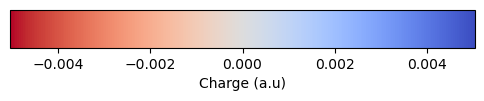

In [3]:
opt_molecule = opt_results["final_molecule"]
scf_drv.cpcm_drv.visualize_cpcm_charges(opt_molecule)

:::{note}
Water is the default solvent. For other solvents, set the dielectric constant:
:::{code}
scf_drv.cpcm_epsilon = 24.5  # ethanol
:::
:::

**Text file**

:::{code}
@jobs
task: scf
@end

@method settings
basis: def2-svp
xcfun: b3lyp
solvation model: cpcm
cpcm epsilon : 78.39
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

(sec:smd)=
### SMD

The solvation model based on density (SMD) combines a self‑consistent reaction‑field description of the electrostatic polarization with empirically parametrized terms for cavitation, dispersion, and solvent–solute interactions based on the solute’s electron density, enabling accurate free‑energy predictions across a wide range of solvents. For further details, see {cite}`Marenich2009`.

In Veloxchem, the electrostatic contribution is determined using the CPCM model.

**Python script**

In [2]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("methanol")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()

scf_drv.solvation_model = "smd"
scf_drv.smd_solvent = "water"

scf_results = scf_drv.compute(molecule, basis)

Reading methanol from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inver

**Text file**

:::{code}
@jobs
task: scf
@end

@method settings
basis: def2-svp
xcfun: b3lyp
solvation model: smd
smd solvent : water
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

(sec:pe)=
## Polarizable embedding

An explicit representation of the environment is available with the polarizable embedding (PE) model. Molecules in the environment are represented by site charges and polarizabilities. VeloxChem supports the PE model for:

- SCF energies
- linear response (UV/vis spectra and more)

The PE model is invoked in input files by giving the name of the associated potential file.

In [3]:
potfile = """@environment
units: angstrom
xyz:
O        1.0991810000      2.2167050000      0.2791250000  water  1
H        2.2673500000      2.2529740000      0.6013580000  water  1
H        0.9984050000      2.8080510000     -0.5840690000  water  1
O       -0.8223690000      0.2141140000     -2.3767710000  water  2
H       -1.5990410000      0.8408210000     -2.6698860000  water  2
H       -0.4683410000      0.4151750000     -1.5365150000  water  2
O        1.7377440000     -2.0168380000     -0.4861090000  water  3
H        2.0753880000     -2.2446490000     -1.3654140000  water  3
H        1.6636970000     -2.7516570000      0.0543720000  water  3
O       -1.0758700000     -0.2692330000      2.5139440000  water  4
H       -0.5822670000     -0.1887880000      1.5058600000  water  4
H       -1.1632420000      0.7082890000      2.8568430000  water  4
@end

@charges
O  -0.67444408  water
H   0.33722206  water
H   0.33722206  water
@end

@polarizabilities
O       5.73935090    0.00000000    0.00000000    5.73935090    0.00000000    5.73935090  water
H       2.30839051    0.00000000    0.00000000    2.30839051    0.00000000    2.30839051  water
H       2.30839051    0.00000000    0.00000000    2.30839051    0.00000000    2.30839051  water
@end"""


with open("solvent.pot", "w") as f:
    f.write(potfile)

In [4]:
import py3Dmol

viewer = py3Dmol.view(width=300, height=300, linked=False)

h2o_xyz = """3
water
O        0.0000000000      0.0000000000      0.0000000000
H        0.6891400000      0.8324710000      0.0000000000
H        0.7224340000     -0.8726890000      0.0000000000
"""

solvent_xyz = """12
water solvent
O        1.0991810000      2.2167050000      0.2791250000
H        2.2673500000      2.2529740000      0.6013580000
H        0.9984050000      2.8080510000     -0.5840690000
O       -0.8223690000      0.2141140000     -2.3767710000
H       -1.5990410000      0.8408210000     -2.6698860000
H       -0.4683410000      0.4151750000     -1.5365150000
O        1.7377440000     -2.0168380000     -0.4861090000
H        2.0753880000     -2.2446490000     -1.3654140000
H        1.6636970000     -2.7516570000      0.0543720000
O       -1.0758700000     -0.2692330000      2.5139440000
H       -0.5822670000     -0.1887880000      1.5058600000
H       -1.1632420000      0.7082890000      2.8568430000
"""

# Load as XYZ so the parser knows the format explicitly
viewer.addModel(h2o_xyz, 'xyz')       # model 0: solute
viewer.addModel(solvent_xyz, 'xyz')   # model 1: solvent

# Clear any default styling, then style per model
viewer.setStyle({}, {})  # reset

viewer.addStyle({'model': 0}, {'stick': {'radius': 0.25, 'colorscheme': 'Jmol'}})
viewer.addStyle({'model': 1}, {'stick': {'radius': 0.45, 'color': '#9bbcff'}})

# Outline and view settings
viewer.setViewStyle({"style": "outline", "color": "black", "width": 0.1})

# Rotate and focus on solute
viewer.rotate(45, "x")
viewer.zoomTo({'model': 0})

viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Python script**

In [5]:
import veloxchem as vlx

solute_xyz = """3
water
O        0.0000000000      0.0000000000      0.0000000000                 
H        0.6891400000      0.8324710000      0.0000000000                 
H        0.7224340000     -0.8726890000      0.0000000000
"""

molecule = vlx.Molecule.read_xyz_string(solute_xyz)
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()

# requires PyFraME until we get an internal PE module
#scf_drv.potfile = "solvent.pot"

scf_results = scf_drv.compute(molecule, basis)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

**Text file**

:::{code}
@jobs
task: scf
@end

@method settings
basis: aug-cc-pvdz
potfile: solvent.pot
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

**Potential file**

The potential file named `solvent.pot` in this example takes the following form. 

In [6]:
print(potfile)

@environment
units: angstrom
xyz:
O        1.0991810000      2.2167050000      0.2791250000  water  1
H        2.2673500000      2.2529740000      0.6013580000  water  1
H        0.9984050000      2.8080510000     -0.5840690000  water  1
O       -0.8223690000      0.2141140000     -2.3767710000  water  2
H       -1.5990410000      0.8408210000     -2.6698860000  water  2
H       -0.4683410000      0.4151750000     -1.5365150000  water  2
O        1.7377440000     -2.0168380000     -0.4861090000  water  3
H        2.0753880000     -2.2446490000     -1.3654140000  water  3
H        1.6636970000     -2.7516570000      0.0543720000  water  3
O       -1.0758700000     -0.2692330000      2.5139440000  water  4
H       -0.5822670000     -0.1887880000      1.5058600000  water  4
H       -1.1632420000      0.7082890000      2.8568430000  water  4
@end

@charges
O  -0.67444408  water
H   0.33722206  water
H   0.33722206  water
@end

@polarizabilities
O       5.73935090    0.00000000    0.0000000

The polarizability components are listed in the order `xx`, `xy`, `xz`, `yy`, `yz`, `zz`.